# Troop 3A Tactical Traffic Report Analysis  
**Author:** Justynn Hammond  
**Role frame:** Senior Data Analyst 
**Assessment note:** I prepared this notebook as my own analysis of the Colorado State Patrol Troop 3A tactical traffic exercise. 

## Objective
My goal in this notebook is to answer the assignment, while also showing how I think through a tactical traffic problem as a senior analyst. I stay grounded in the supplied dataset only. I do not infer facts that are not present in the file.


In [32]:
# Copyright / authorship note
# Analysis narrative and notebook structure prepared by Justynn Hammond.
# This notebook is designed as a portfolio-ready, reproducible version of the
# Troop 3A tactical traffic report exercise.

"""
Author: Justynn Hammond
Role framing: Senior Data Analyst

Purpose:
This notebook analyzes Colorado State Patrol Troop 3A Q2 crash data from 2021-2025.
It is structured to show how I move from data cleaning to pattern detection, hotspot
analysis, visual storytelling, and operational recommendations.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
import re
import textwrap
from pathlib import Path

DATA_PATH = Path("../data/troop3A_crash_data.xlsx")

if not DATA_PATH.exists():
    raise FileNotFoundError("Data file not found. Place it in the /data folder.")

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 200,
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "legend.frameon": False,
    "grid.alpha": 0.22,
    "grid.linestyle": "--",
})

PRIMARY = "#315C9B"     # crash volume
SECONDARY = "#D1495B"   # severity / fatal-injury burden
ACCENT = "#3CAEA3"      # supporting accent
DARK = "#263238"

DATA_PATH = Path("../data/troop3A_crash_data.xlsx")
OUTPUT_DIR = Path("charts")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

def executive_axes(ax, title, subtitle=None, xlabel=None, ylabel=None):
    ax.set_title(title, loc="left", pad=12, color=DARK, fontweight="bold")
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=9, color="#5B6570", va="bottom")
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

## 1) Load the source file
I start by loading the exercise workbook exactly as provided. The worksheet contains crash-level records for Q2 (April, May, June) across 2021 through 2025.


In [33]:
df = pd.read_excel(DATA_PATH)
df.head()

,CaseTrackingID,AccidentDate,Year,Month,Day,DayOfWeek,AccidentTime,Hour,AccidentCausalFactor,DistrictNumber,LocationCountyName,LocationRoadName,NumberKilled,NumberInjured,FIP,HighwayName,HighwayMilePoint,HighwayMilePointRound,ReferencePointName,ReferencePointAtName
0,3A210443,2021-04-01,2021,4,1,Thursday,16:20,16,Inattentive to driving,3A,Weld,HIGHWAY 85,0,0,Property,H85,238.0,238,HIGHWAY 85,MILEPOINT 238
1,3A210442,2021-04-01,2021,4,1,Thursday,16:54,16,Speed,3A,Weld,WELD COUNTY ROAD 27,0,0,Property,R3A02,NaN,0,WELD COUNTY ROAD 27,WELD COUNTY ROAD 64.5
2,3A210444,2021-04-01,2021,4,1,Thursday,17:01,17,Failed to yield right of way,3A,Weld,EAST INTERSTATE 25 FRONTAGE ROAD,0,0,Property,R3A01,NaN,0,EAST INTERSTATE 25 FRONTAGE ROAD,WELD COUNTY ROAD 50
3,3A210445,2021-04-01,2021,4,1,Thursday,17:11,17,Inattentive to driving,3A,Weld,HIGHWAY 392,0,0,Property,H392,109.5,110,HIGHWAY 392,WELD COUNTY ROAD 27
4,3A210450,2021-04-02,2021,4,2,Friday,10:50,10,Impaired,3A,Weld,54TH,0,0,Property,R3A02,NaN,0,54TH ST,WELD COUNTY ROAD 378


## 2) Standardize key fields
The assignment specifically noted that road names in `ReferencePointName` and `ReferencePointAtName` may need to be cleaned because troopers enter the same locations in different ways. I normalize the major naming variations so I can produce cleaner corridor and hotspot analysis.


In [34]:
def clean_road(value):
    value = str(value).upper().strip()
    value = re.sub(r"\s+", " ", value)
    replacements = {
        "INTERSATE 25": "INTERSTATE 25",
        "I25": "INTERSTATE 25",
        "I 25": "INTERSTATE 25",
        "I-25": "INTERSTATE 25",
        "I76": "INTERSTATE 76",
        "I 76": "INTERSTATE 76",
        "I-76": "INTERSTATE 76",
    }
    return replacements.get(value, value)

def clean_ref(value):
    value = "" if pd.isna(value) else str(value).upper().strip()
    value = re.sub(r"\s+", " ", value)
    value = value.replace(" PKWY", " PARKWAY")
    value = value.replace("INTERSATE", "INTERSTATE")
    return value

df["road_clean"] = df["LocationRoadName"].map(clean_road)
df["ref_clean"] = df["ReferencePointName"].map(clean_road)
df["at_clean"] = df["ReferencePointAtName"].map(clean_ref)
df["is_fatal"] = df["NumberKilled"] > 0
df["is_injury_any"] = df["NumberInjured"] > 0
df["is_fi"] = df["is_fatal"] | df["is_injury_any"]
df["severity"] = np.select(
    [df["is_fatal"], df["is_injury_any"]],
    ["Fatal", "Injury"],
    default="PDO"
)
df["mile_round5"] = (df["HighwayMilePointRound"] // 5) * 5
df["hour_band"] = pd.cut(
    df["Hour"],
    bins=[-1, 4, 8, 11, 15, 18, 23],
    labels=["Overnight", "AM Peak", "Late Morning", "Midday/Afternoon", "PM Peak", "Evening"]
)

df[["LocationRoadName", "road_clean", "ReferencePointAtName", "at_clean"]].head(10)

,LocationRoadName,road_clean,ReferencePointAtName,at_clean
0,HIGHWAY 85,HIGHWAY 85,MILEPOINT 238,MILEPOINT 238
1,WELD COUNTY ROAD 27,WELD COUNTY ROAD 27,WELD COUNTY ROAD 64.5,WELD COUNTY ROAD 64.5
2,EAST INTERSTATE 25 FRONTAGE ROAD,EAST INTERSTATE 25 FRONTAGE ROAD,WELD COUNTY ROAD 50,WELD COUNTY ROAD 50
3,HIGHWAY 392,HIGHWAY 392,WELD COUNTY ROAD 27,WELD COUNTY ROAD 27
4,54TH,54TH,WELD COUNTY ROAD 378,WELD COUNTY ROAD 378
5,HIGHWAY 14,HIGHWAY 14,MILEPOINT 199,MILEPOINT 199
6,WELD COUNTY ROAD 17,WELD COUNTY ROAD 17,WELD COUNTY ROAD 28,WELD COUNTY ROAD 28
7,INTERSATE 25,INTERSTATE 25,MILEPOINT 251,MILEPOINT 251
8,INTERSATE 25,INTERSTATE 25,MILEPOINT 253,MILEPOINT 253
9,INTERSTATE 25,INTERSTATE 25,MILEPOINT 250,MILEPOINT 250


## 3) Core metrics
Before I go into tactical detail, I anchor the briefing with a small set of command-level metrics.


In [35]:
summary = {
    "Total crashes": len(df),
    "Fatal crashes": int(df["is_fatal"].sum()),
    "Crashes with injury involvement": int(df["is_injury_any"].sum()),
    "Fatal or injury crashes": int(df["is_fi"].sum()),
    "Years covered": f"{df['Year'].min()}-{df['Year'].max()}",
    "Months covered": "April-June (Q2)"
}
pd.Series(summary)

Total crashes                                 1909
Fatal crashes                                   42
Crashes with injury involvement                392
Fatal or injury crashes                        420
Years covered                            2021-2025
Months covered                     April-June (Q2)
dtype: object

### My first read of the data
My first read is that Troop 3A has both a **volume problem** and a **severity problem**, but they do not occur in the same places:

- **I-25** is the dominant volume corridor.
- **Highway 85, Highway 392, Highway 14, Highway 52, and I-76** carry lower volume but higher severe-crash exposure.
- **Following too closely** is the biggest volume driver.
- **Impaired driving** is the strongest severe-crash driver.


## 4) Trend analysis by year
I want to know whether the Q2 crash burden is stable or worsening across the five-year window.


In [36]:
year_stats = df.groupby("Year").agg(
    crashes=("CaseTrackingID", "count"),
    fatal=("is_fatal", "sum"),
    injury_involved=("is_injury_any", "sum"),
    fatal_or_injury=("is_fi", "sum")
)
year_stats["fi_rate"] = (year_stats["fatal_or_injury"] / year_stats["crashes"]).round(3)
year_stats

,crashes,fatal,injury_involved,fatal_or_injury,fi_rate
Year,,,,,
2021,336,5,64,67,0.199
2022,350,7,75,80,0.229
2023,387,7,78,82,0.212
2024,398,10,86,93,0.234
2025,438,13,89,98,0.224


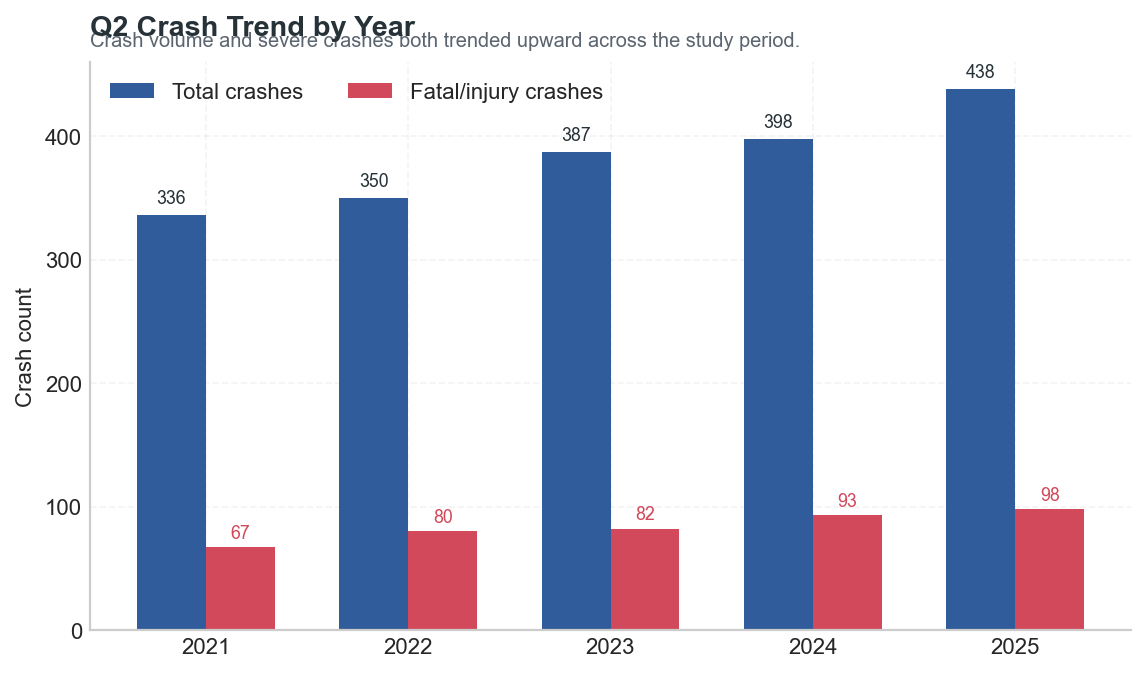

In [37]:
fig, ax = plt.subplots(figsize=(8.4, 5.0))
x = np.arange(len(year_stats))
width = 0.34

# Bars
bars_total = ax.bar(
    x - width / 2,
    year_stats["crashes"],
    width=width,
    color=PRIMARY,
    label="Total crashes"
)

bars_fi = ax.bar(
    x + width / 2,
    year_stats["fatal_or_injury"],
    width=width,
    color=SECONDARY,
    label="Fatal/injury crashes"
)

# Executive styling
executive_axes(
    ax,
    "Q2 Crash Trend by Year",
    "Crash volume and severe crashes both trended upward across the study period.",
    ylabel="Crash count"
)

# X-axis
ax.set_xticks(x)
ax.set_xticklabels(year_stats.index.astype(str))

# Data labels
for bar in bars_total:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 6,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=8,
        color=DARK
    )

for bar in bars_fi:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 4,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=8,
        color=SECONDARY
    )

# Legend
ax.legend(ncol=2, loc="upper left")

# Layout and save
fig.subplots_adjust(top=0.82)
fig.savefig(OUTPUT_DIR / "01_year_trend.png", bbox_inches="tight", pad_inches=0.35)
plt.show()

**My brief:** Crash volume increased from **336 in 2021** to **438 in 2025**, which is a **30.4% increase** over the study window. The highest fatal count in the supplied period occurs in **2025 (13 fatal crashes)**. This matters because it tells me this is not a static traffic picture; the burden is building, not flattening.


## 5) Corridor analysis
The next question I ask is simple: **which roads are carrying the problem?** I care about both absolute volume and severe-crash share because those can point to different deployment strategies.


In [38]:
road_stats = (
    df.groupby("road_clean")
      .agg(
          crashes=("CaseTrackingID", "count"),
          fatal=("is_fatal", "sum"),
          injury_involved=("is_injury_any", "sum"),
          fatal_or_injury=("is_fi", "sum"),
      )
      .sort_values("crashes", ascending=False)
)
road_stats["fi_rate"] = (road_stats["fatal_or_injury"] / road_stats["crashes"]).round(3)
road_stats.head(15)

,crashes,fatal,injury_involved,fatal_or_injury,fi_rate
road_clean,,,,,
INTERSTATE 25,751,2,88,89,0.119
HIGHWAY 85,141,6,42,47,0.333
HIGHWAY 392,99,3,26,28,0.283
HIGHWAY 34,98,5,18,19,0.194
INTERSTATE 76,54,3,14,16,0.296
HIGHWAY 14,50,5,13,16,0.320
HIGHWAY 60,47,1,10,11,0.234
HIGHWAY 119,35,0,4,4,0.114
HIGHWAY 52,32,0,11,11,0.344


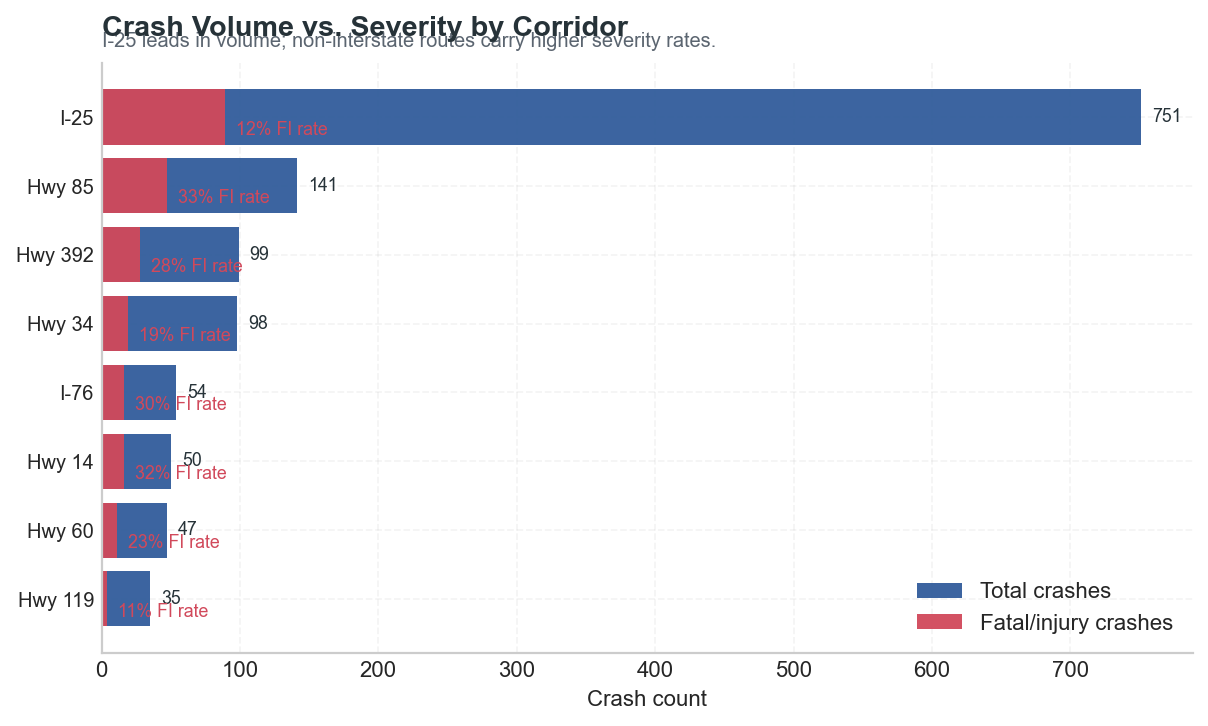

In [39]:
plot_df = road_stats.head(8).copy().sort_values("crashes")

fig, ax = plt.subplots(figsize=(8.8, 5.2))
y = np.arange(len(plot_df))

# Bars
bars_total = ax.barh(
    y,
    plot_df["crashes"],
    color=PRIMARY,
    alpha=0.95,
    label="Total crashes"
)

bars_fi = ax.barh(
    y,
    plot_df["fatal_or_injury"],
    color=SECONDARY,
    alpha=0.95,
    label="Fatal/injury crashes"
)

# Title / subtitle
executive_axes(
    ax,
    "Crash Volume vs. Severity by Corridor",
    "I-25 leads in volume; non-interstate routes carry higher severity rates.",
    xlabel="Crash count"
)

# Y labels
ax.set_yticks(y)
ax.set_yticklabels(
    plot_df.index.str.replace("INTERSTATE ", "I-").str.replace("HIGHWAY ", "Hwy "),
    fontsize=9
)

# Value labels
for bar, rate in zip(bars_total, plot_df["fi_rate"]):
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2

    ax.text(
        width + 8,
        y_pos,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=8,
        color=DARK
    )

for bar, rate in zip(bars_fi, plot_df["fi_rate"]):
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2

    ax.text(
        width + 8,
        y_pos - 0.18,
        f"{rate:.0%} FI rate",
        va="center",
        ha="left",
        fontsize=8,
        color=SECONDARY
    )

# Legend
ax.legend(loc="lower right")

# Final layout
fig.subplots_adjust(top=0.82)
fig.savefig(OUTPUT_DIR / "02_top_corridors.png", bbox_inches="tight", pad_inches=0.35)
plt.show()

### My corridor readout
This the most important insight in the whole assignment.

- **I-25** is the clear volume problem with **751 crashes** and **89 fatal/injury crashes**.
- **Highway 85** is the strongest severe corridor after I-25 with **141 crashes**, **47 fatal/injury crashes**, and a **33.3% fatal/injury rate**.
- **Highway 392** also stands out with **99 crashes** and **28 fatal/injury crashes**.
- **I-76** and **Highway 14** have much smaller volumes than I-25, but both have a materially higher severe-crash share.

That tells me I would not deploy every road the same way. On I-25 I would think in terms of **high-volume crash suppression**. On Highway 85 and similar corridors, I would think in terms of **high-severity risk reduction**.


## 6) 5-mile hotspot analysis
The assignment specifically asked for 5- to 10-mile stretches or areas with the highest crash frequency. I use the rounded highway mile point field and roll it up into 5-mile bands.


In [40]:
hotspots = (
    df[df["HighwayMilePoint"].notna()]
      .groupby(["road_clean", "mile_round5"])
      .agg(
          crashes=("CaseTrackingID", "count"),
          fatal=("is_fatal", "sum"),
          fatal_or_injury=("is_fi", "sum"),
      )
      .reset_index()
)
hotspots["segment"] = hotspots["mile_round5"].astype(int).astype(str) + "-" + (hotspots["mile_round5"] + 4).astype(int).astype(str)
hotspots = hotspots.sort_values(["crashes", "fatal_or_injury", "fatal"], ascending=False)
hotspots.head(15)

,road_clean,mile_round5,crashes,fatal,fatal_or_injury,segment
88,INTERSTATE 25,250,229,0,25,250-254
87,INTERSTATE 25,245,179,0,18,245-249
86,INTERSTATE 25,240,130,1,16,240-244
85,INTERSTATE 25,235,120,0,12,235-239
84,INTERSTATE 25,230,56,1,14,230-234
24,HIGHWAY 34,95,44,0,2,95-99
61,HIGHWAY 85,235,30,0,10,235-239
38,HIGHWAY 392,110,30,1,8,110-114
55,HIGHWAY 60,15,29,1,7,15-19
6,HIGHWAY 119,60,29,0,3,60-64


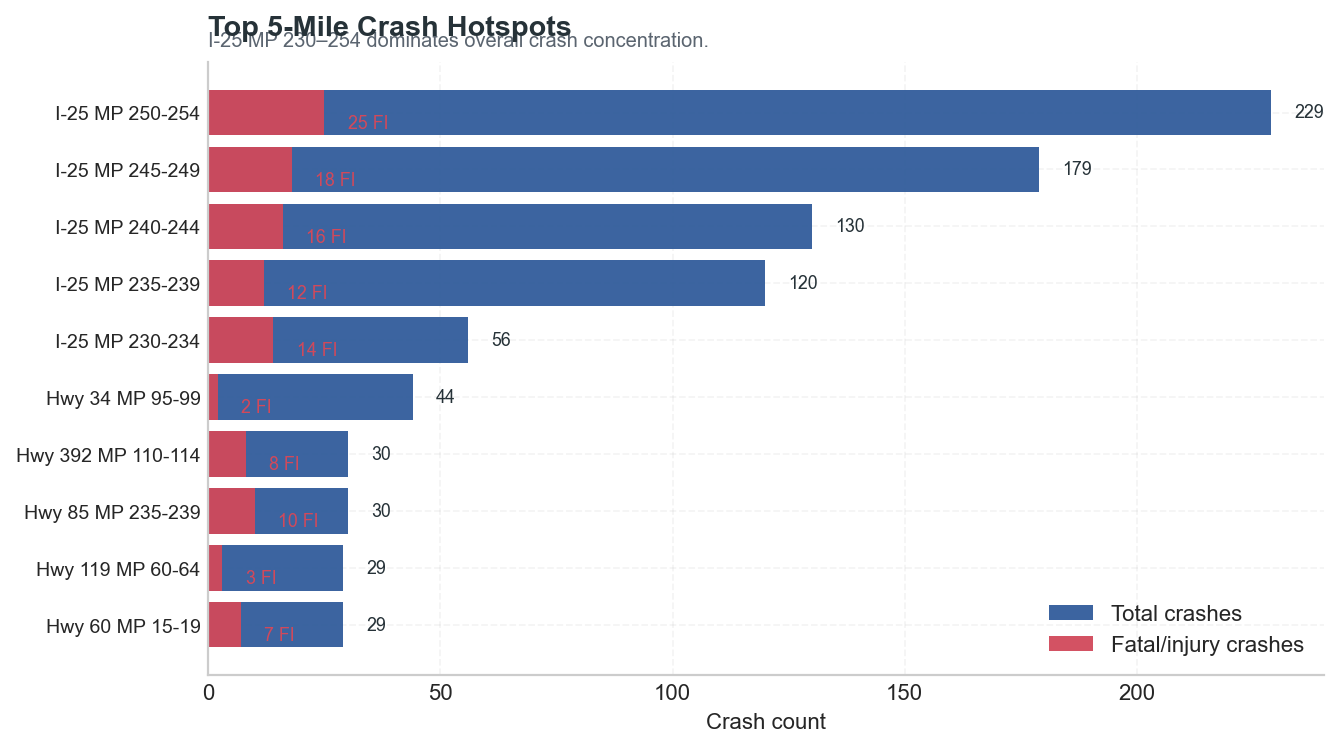

In [41]:
plot_hotspots = hotspots.head(10).copy()

plot_hotspots["label"] = (
    plot_hotspots["road_clean"]
    .str.replace("INTERSTATE ", "I-", regex=False)
    .str.replace("HIGHWAY ", "Hwy ", regex=False)
    + " MP " + plot_hotspots["segment"]
)

plot_hotspots = plot_hotspots.sort_values("crashes")

fig, ax = plt.subplots(figsize=(9.0, 5.4))
y = np.arange(len(plot_hotspots))

# Bars
bars_total = ax.barh(
    y,
    plot_hotspots["crashes"],
    color=PRIMARY,
    alpha=0.95,
    label="Total crashes"
)

bars_fi = ax.barh(
    y,
    plot_hotspots["fatal_or_injury"],
    color=SECONDARY,
    alpha=0.95,
    label="Fatal/injury crashes"
)

# Title / subtitle
executive_axes(
    ax,
    "Top 5-Mile Crash Hotspots",
    "I-25 MP 230–254 dominates overall crash concentration.",
    xlabel="Crash count"
)

# Y labels
ax.set_yticks(y)
ax.set_yticklabels(plot_hotspots["label"], fontsize=8.8)

# Value labels
for bar in bars_total:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    ax.text(
        width + 5,
        y_pos,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=8,
        color=DARK
    )

for bar, severe in zip(bars_fi, plot_hotspots["fatal_or_injury"]):
    if severe > 0:
        width = bar.get_width()
        y_pos = bar.get_y() + bar.get_height() / 2
        ax.text(
            width + 5,
            y_pos - 0.18,
            f"{int(severe)} FI",
            va="center",
            ha="left",
            fontsize=8,
            color=SECONDARY
        )

# Legend
ax.legend(loc="lower right")

# Final layout
fig.subplots_adjust(top=0.82)
fig.savefig(OUTPUT_DIR / "04_hotspots.png", bbox_inches="tight", pad_inches=0.35)
plt.show()

### What stood out in the hotspot view
The hotspot story is dominated by **I-25 MP 230-254**.

The five highest 5-mile bands in the dataset are:

1. **I-25 MP 250-254** — 229 crashes, 25 fatal/injury  
2. **I-25 MP 245-249** — 179 crashes, 18 fatal/injury  
3. **I-25 MP 240-244** — 130 crashes, 16 fatal/injury  
4. **I-25 MP 235-239** — 120 crashes, 12 fatal/injury  
5. **I-25 MP 230-234** — 56 crashes, 14 fatal/injury  

Outside I-25, the strongest recurring hotspot bands are:

- **Highway 85 MP 235-239 / 255-259 / 270-274**
- **Highway 392 MP 110-119**
- **Highway 60 MP 15-19**
- **I-76 MP 45-54**

My briefing to command staff would explicitly distinguish between **network-wide problem roads** and **segment-level deployment zones**.


## 7) Time-of-day and day-of-week analysis
This tactical report alsotells the commander **when** the problem is happening, not just where.


In [42]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_stats = (
    df.groupby("DayOfWeek")
      .agg(crashes=("CaseTrackingID", "count"), fatal=("is_fatal", "sum"), fatal_or_injury=("is_fi", "sum"))
      .reindex(day_order)
)
day_stats["fi_rate"] = (day_stats["fatal_or_injury"] / day_stats["crashes"]).round(3)

hour_stats = df.groupby("Hour").agg(
    crashes=("CaseTrackingID", "count"),
    fatal=("is_fatal", "sum"),
    fatal_or_injury=("is_fi", "sum"),
)
hour_stats["fi_rate"] = (hour_stats["fatal_or_injury"] / hour_stats["crashes"]).round(3)

day_stats, hour_stats.head()

(           crashes  fatal  fatal_or_injury  fi_rate
 DayOfWeek                                          
 Monday         250     10               47    0.188
 Tuesday        264      4               50    0.189
 Wednesday      298      7               68    0.228
 Thursday       300      6               76    0.253
 Friday         304      4               68    0.224
 Saturday       277      6               64    0.231
 Sunday         216      5               47    0.218,
       crashes  fatal  fatal_or_injury  fi_rate
 Hour                                          
 0          35      3               12    0.343
 1          28      1               10    0.357
 2          28      2               10    0.357
 3          14      1                6    0.429
 4          22      1                8    0.364)

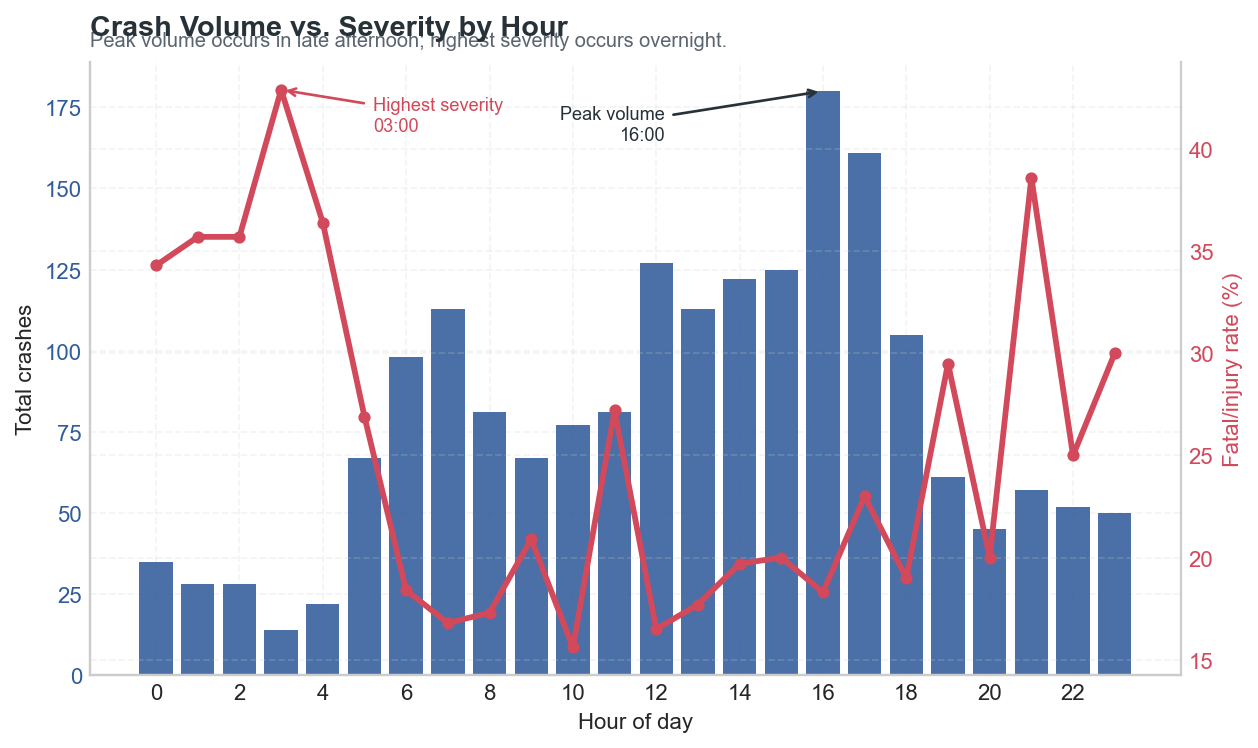

In [43]:
fig, ax1 = plt.subplots(figsize=(8.8, 5.4))

# Bars: total crash volume
ax1.bar(
    hour_stats.index,
    hour_stats["crashes"],
    color=PRIMARY,
    alpha=0.88,
    width=0.8
)

executive_axes(
    ax1,
    "Crash Volume vs. Severity by Hour",
    "Peak volume occurs in late afternoon; highest severity occurs overnight.",
    xlabel="Hour of day",
    ylabel="Total crashes"
)

ax1.set_xticks(range(0, 24, 2))
ax1.tick_params(axis="y", labelcolor=PRIMARY)

# Line: fatal/injury rate
ax2 = ax1.twinx()
ax2.plot(
    hour_stats.index,
    hour_stats["fi_rate"] * 100,
    color=SECONDARY,
    marker="o",
    linewidth=2.6,
    markersize=4.5
)
ax2.set_ylabel("Fatal/injury rate (%)", color=SECONDARY)
ax2.tick_params(axis="y", labelcolor=SECONDARY)
ax2.spines["top"].set_visible(False)

# Key points
peak_hr = int(hour_stats["crashes"].idxmax())
sev_hr = int(hour_stats["fi_rate"].idxmax())

ax2.annotate(
    f"Highest severity\n{sev_hr:02d}:00",
    xy=(sev_hr, hour_stats.loc[sev_hr, "fi_rate"] * 100),
    xytext=(sev_hr + 2.2, hour_stats["fi_rate"].max() * 100 - 2),
    arrowprops=dict(arrowstyle="->", color=SECONDARY, lw=1.2),
    fontsize=8.2,
    color=SECONDARY,
    ha="left"
)

ax1.annotate(
    f"Peak volume\n{peak_hr:02d}:00",
    xy=(peak_hr, hour_stats.loc[peak_hr, "crashes"]),
    xytext=(peak_hr - 3.8, hour_stats["crashes"].max() - 15),
    arrowprops=dict(arrowstyle="->", color=DARK, lw=1.2),
    fontsize=8.2,
    color=DARK,
    ha="right"
)

# Final layout
fig.subplots_adjust(top=0.82)
fig.savefig(OUTPUT_DIR / "03_hour_profile.png", bbox_inches="tight", pad_inches=0.35)
plt.show()

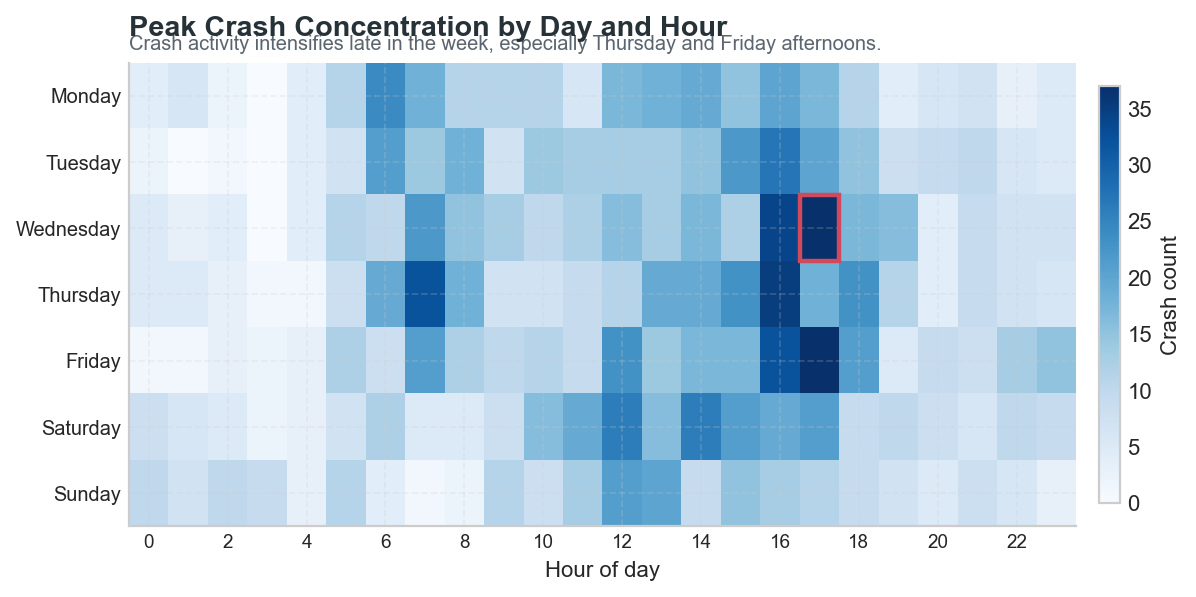

In [44]:
heatmap = (
    df.pivot_table(
        index="DayOfWeek",
        columns="Hour",
        values="CaseTrackingID",
        aggfunc="count"
    )
    .reindex(day_order)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(9.2, 4.2))

im = ax.imshow(
    heatmap.values,
    aspect="auto",
    cmap="Blues"
)

executive_axes(
    ax,
    "Peak Crash Concentration by Day and Hour",
    "Crash activity intensifies late in the week, especially Thursday and Friday afternoons.",
    xlabel="Hour of day"
)

ax.set_yticks(range(len(day_order)))
ax.set_yticklabels(day_order, fontsize=9)

ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels(range(0, 24, 2), fontsize=8.5)

cbar = fig.colorbar(im, ax=ax, shrink=0.9, pad=0.02)
cbar.set_label("Crash count")

# Highlight the single highest cell
max_idx = np.unravel_index(np.argmax(heatmap.values), heatmap.values.shape)
ax.add_patch(
    plt.Rectangle(
        (max_idx[1] - 0.5, max_idx[0] - 0.5),
        1,
        1,
        fill=False,
        edgecolor=SECONDARY,
        lw=2
    )
)

fig.subplots_adjust(top=0.80)
fig.savefig(OUTPUT_DIR / "06_heatmap.png", bbox_inches="tight", pad_inches=0.35)
plt.show()

### My time-based interpretation
I see two different time stories in this data:

1. **Crash volume peaks in the afternoon and PM peak window**, especially around **1600-1700**.
2. **Severity rises overnight**, even though volume drops.

That means I would not use one scheduling model for all enforcement. I would use:

- **Afternoon deployment** on the high-volume corridors to suppress total crash counts.
- **Night / overnight deployment** on the higher-severity corridors to target fatal/injury risk.

By day of week, **Thursday and Friday** carry the highest overall crash burden in the supplied file.


## 8) Causal factor analysis
Once I know where and when the crashes are happening, I ask what the reported causal patterns look like. 


In [45]:
causal = (
    df.groupby("AccidentCausalFactor")
      .agg(
          crashes=("CaseTrackingID", "count"),
          fatal=("is_fatal", "sum"),
          injury_involved=("is_injury_any", "sum"),
          fatal_or_injury=("is_fi", "sum"),
      )
      .sort_values("crashes", ascending=False)
)
causal["fi_rate"] = (causal["fatal_or_injury"] / causal["crashes"]).round(3)
causal.head(15)

,crashes,fatal,injury_involved,fatal_or_injury,fi_rate
AccidentCausalFactor,,,,,
Following too closely,462,0,45,45,0.097
Inattentive to driving,312,2,66,67,0.215
Lane violation,243,5,33,37,0.152
Failed to yield right of way,166,3,61,62,0.373
Impaired,164,17,63,76,0.463
Speed,138,0,27,27,0.196
Asleep,65,0,22,22,0.338
All others,56,1,8,9,0.161
Improper turn,47,2,7,9,0.191


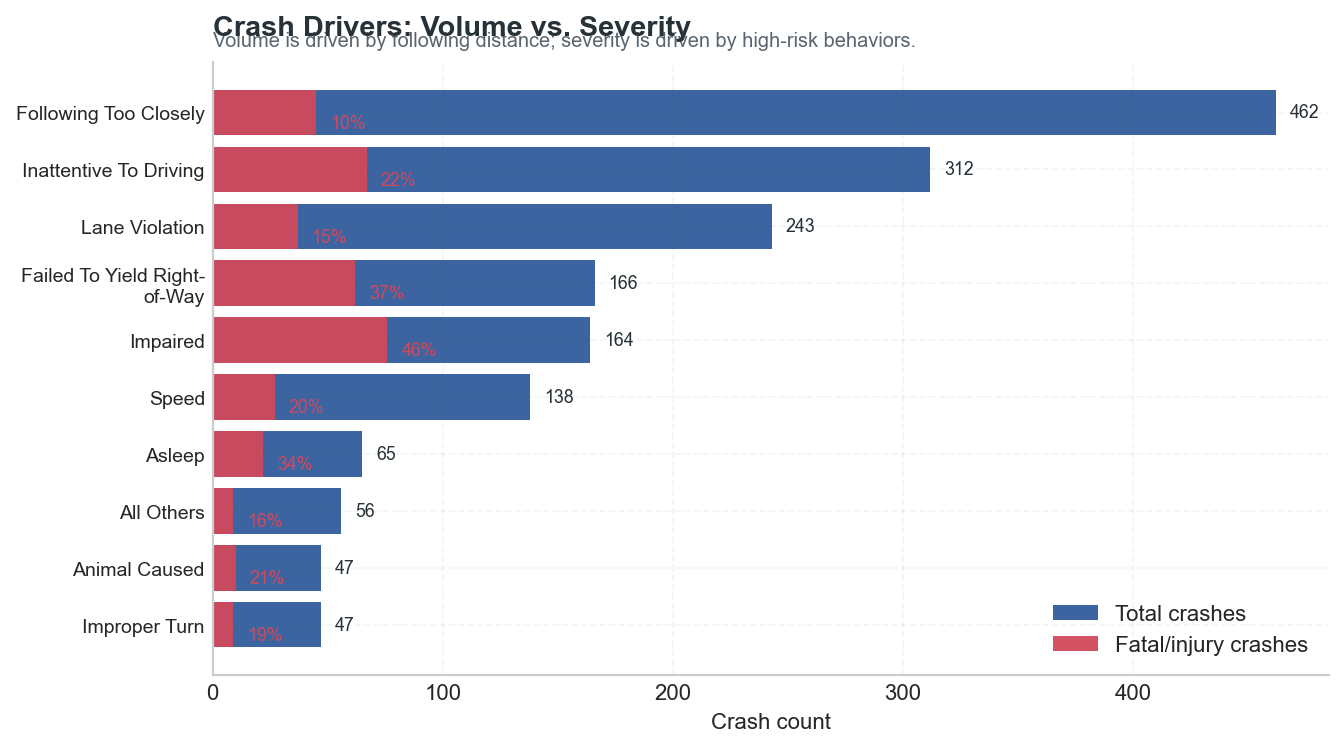

In [46]:
plot_causal = causal.head(10).copy().sort_values("crashes")

fig, ax = plt.subplots(figsize=(9.0, 5.4))
y = np.arange(len(plot_causal))

# Bars
bars_total = ax.barh(
    y,
    plot_causal["crashes"],
    color=PRIMARY,
    alpha=0.95,
    label="Total crashes"
)

bars_fi = ax.barh(
    y,
    plot_causal["fatal_or_injury"],
    color=SECONDARY,
    alpha=0.95,
    label="Fatal/injury crashes"
)

# Title / subtitle
executive_axes(
    ax,
    "Crash Drivers: Volume vs. Severity",
    "Volume is driven by following distance; severity is driven by high-risk behaviors.",
    xlabel="Crash count"
)

# Y labels (clean + wrapped)
labels = [
    textwrap.fill(
        idx.title().replace("Right Of Way", "Right-of-Way"),
        22
    )
    for idx in plot_causal.index
]

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8.8)

# Value labels
for bar in bars_total:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2

    ax.text(
        width + 6,
        y_pos,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=8,
        color=DARK
    )

for bar, rate in zip(bars_fi, plot_causal["fi_rate"]):
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2

    ax.text(
        width + 6,
        y_pos - 0.18,
        f"{rate:.0%}",
        va="center",
        ha="left",
        fontsize=8,
        color=SECONDARY
    )

# Legend
ax.legend(loc="lower right")

# Final layout
fig.subplots_adjust(top=0.82)
fig.savefig(OUTPUT_DIR / "05_causal_factors.png", bbox_inches="tight", pad_inches=0.35)
plt.show()

### My factor readout
This is another place where volume and severity split apart:

- **Following too closely** drives the most crashes overall (**462**), and it is heavily concentrated on **I-25**.
- **Impaired driving** is the strongest severe-crash signal in the dataset with **164 crashes**, **76 fatal/injury crashes**, and **17 fatal crashes**.
- **Failed to yield right of way** and **disregard stop sign/traffic device** stand out as actionable intersection / crossing-conflict factors on non-interstate routes.
- **Asleep** appears as a notable factor on **I-76**, which supports a fatigue-focused read on that corridor.

The practical implication is that the same "speed enforcement everywhere" posture would miss a lot of what this file is actually telling us.


## 9) Corridor-specific drilldown
This is where I'm showcasing the extra layer of analysis. I'm looking at road-specific crash signatures and what that actually looks like.


In [47]:
priority_roads = ["INTERSTATE 25", "HIGHWAY 85", "HIGHWAY 392", "HIGHWAY 34", "INTERSTATE 76", "HIGHWAY 14"]

road_factor_profiles = {}
for road in priority_roads:
    road_factor_profiles[road] = (
        df[df["road_clean"] == road]
          .groupby("AccidentCausalFactor")
          .agg(crashes=("CaseTrackingID", "count"), fatal_or_injury=("is_fi", "sum"))
          .sort_values(["crashes", "fatal_or_injury"], ascending=False)
          .head(6)
    )

road_factor_profiles["INTERSTATE 25"]

,crashes,fatal_or_injury
AccidentCausalFactor,,
Following too closely,343,32
Lane violation,117,14
Inattentive to driving,113,21
Speed,63,10
Impaired,25,5
Asleep,21,2


### Why this matters
The drilldown I use during a briefing:

- **I-25:** following too closely, lane violation, and inattention dominate. I see that as a congestion, spacing, and lane-discipline problem.
- **Highway 85:** impairment and inattention stand out much more strongly. I see this as a high-severity corridor needing a different posture than I-25.
- **Highway 392:** right-of-way failure and inattention matter more here, which points toward crossing conflict and intersection control.
- **I-76:** fatigue / asleep is much more visible here than on the other main roads.



## 10) Watchlist intersections / crossing points
I also want to know whether the file points to recurring paired locations. This is useful for short-duration directed enforcement or engineering coordination.


In [48]:
pairs = (
    df[df["at_clean"] != ""]
      .groupby(["road_clean", "at_clean"])
      .agg(crashes=("CaseTrackingID", "count"), fatal=("is_fatal", "sum"), fatal_or_injury=("is_fi", "sum"))
      .reset_index()
      .sort_values(["crashes", "fatal_or_injury", "fatal"], ascending=False)
)
pairs.head(12)

,road_clean,at_clean,crashes,fatal,fatal_or_injury
131,HIGHWAY 60,TWO RIVERS PARKWAY,12,0,5
260,WELD COUNTY ROAD 17,WELD COUNTY ROAD 34,11,1,4
144,HIGHWAY 85,HIGHWAY 392,10,0,6
102,HIGHWAY 392,WELD COUNTY ROAD 27,10,0,2
345,WELD COUNTY ROAD 34,WELD COUNTY ROAD 17,7,0,4
82,HIGHWAY 34,WELD COUNTY ROAD 17,7,0,1
506,WELD COUNTY ROAD 74,WELD COUNTY ROAD 27,7,0,1
135,HIGHWAY 60,WELD COUNTY ROAD 46,6,0,2
171,HIGHWAY 85,WELD COUNTY ROAD 6,6,0,2
80,HIGHWAY 34,WELD COUNTY ROAD 13,6,0,1


### My watchlist from the paired-location view
The paired-location view supports targeted attention on:

- **Highway 60 / Two Rivers Parkway**
- **Weld County Road 17 / Weld County Road 34**
- **Highway 85 / Highway 392**
- **Highway 392 / Weld County Road 27**

This is a tactical watchlist rather than a final conclusion, because the file is strong enough to show recurrence, but not enough by itself to prove roadway design causality.


## 11) Tactical recommendations for the Troop Commander
I want the report to end with action, not just description. I keep the actions grounded in what the data supports.

### A. Volume suppression strategy
I would prioritize **I-25 MP 230-254** for directed enforcement during the **1400-1800** window, because that is the clearest high-volume crash concentration in the file. I would focus on:
- following distance
- lane discipline
- inattentive driving visibility
- short-duration saturation patrols at the hotspot bands

### B. High-severity reduction strategy
I would prioritize **Highway 85**, **Highway 392**, **I-76**, and **Highway 14** for high-severity countermeasures. Based on the factor mix, I would consider:
- DUI emphasis details on Highway 85
- right-of-way and traffic-control compliance details on Highway 392 and selected junctions
- fatigue / alertness messaging and directed enforcement on I-76
- nighttime and shoulder-period deployment where severe-crash share is elevated

### C. Low-cost operational enhancements
Without going into heavy scope creep, I would recommend a small set of data-supported enhancements:
- portable speed feedback trailers at recurring hotspot bands
- temporary dynamic message boards on I-25 for following distance and lane discipline
- short recurring enforcement windows rather than all-day blanket coverage
- a standing hotspot watchlist refreshed each quarter so deployment follows the data, not habit

### Important caveat
I would clearly let stakeholders know that the crash file support **operational targeting**, not guaranteed cause-and-effect claims. I can say these areas and factors recur. I cannot say, from this file alone, exactly how much any one intervention will reduce crashes.


## 12) Executive summary final report
> I analyzed 1,909 Q2 crashes for Troop 3A across 2021-2025 and found that crash volume increased steadily over the five-year period, reaching its highest level in 2025. The dominant volume corridor is I-25, especially MP 230-254, where multiple 5-mile bands account for the largest concentration of crashes in the entire file.  
>
> The most important operational distinction in the dataset is that volume and severity are not the same problem. I-25 drives the highest crash count, but Highway 85, Highway 392, Highway 14, Highway 52, and I-76 carry a higher fatal/injury share and should be treated as high-severity corridors.  
>
> Following too closely is the largest crash-volume factor, while impaired driving is the strongest severe-crash factor. Afternoon and PM-peak hours drive the most crash activity overall, but overnight hours carry a higher fatal/injury rate. Based on this pattern, I would recommend a split deployment model: volume suppression on I-25 and severity-focused enforcement on the higher-risk non-interstate corridors.
